In [1]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

artifact = joblib.load('../models/churn_model.pkl')
model = artifact['model']

df = pd.read_csv('../data/processed/telco_featured.csv')

CAT_COLS = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'tenure_segment'
]
NUM_COLS = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'monthly_charges_per_service', 'has_multiple_contracts'
]

X = df[CAT_COLS + NUM_COLS]

In [11]:
# Возьмем только LightGBM
preprocessor = model.named_steps['preprocessor']
lgbm_model = model.named_steps['classifier'].estimators_[0]

X_transformed = preprocessor.transform(X)

explainer = shap.TreeExplainer(lgbm_model)
shap_values_raw = explainer.shap_values(X_transformed)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    shap_values = shap_values_raw

print(f"Type: {type(shap_values_raw)}")

Type: <class 'numpy.ndarray'>


C:\Users\User\Desktop\Projects\churn-prediction\venv\lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


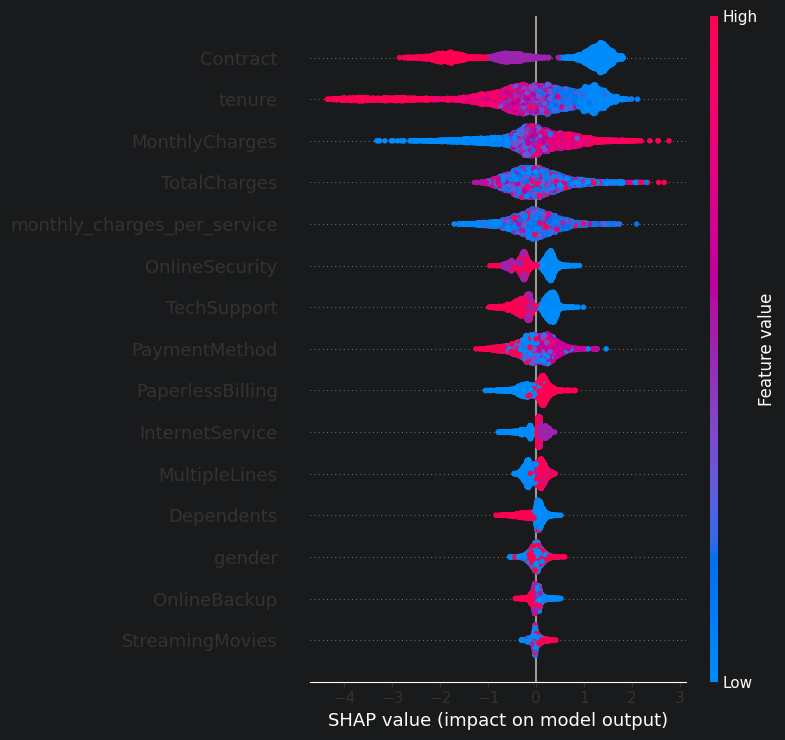

Готово!


In [12]:
feature_names = CAT_COLS + NUM_COLS

plt.figure()
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Готово!")